## Food Recall Analysis: USDA FSIS Data 

**Author**: Deepti Jaswal
**Date**: 15 May 2026
**Last Updated**: 20 May 2026
**Tools**: Python, Pandas, Matplotlib, Regex, Seaborn
**Data Source**: USDA Food Safety and Inspection Service (FSIS) 

## Project Overview

This project analyzes food recall data from the USDA FSIS database to answer three key questions: 

1. What are the most common reasons for food recalls?
2. Which companies are repeat offenders?
3. Are there seasonal patterns in recalls?

## Key Findings Summary 

1. **Product Contamination** is the number 1 recall reason (37% of incidents recorded).
2. **Tyson Foods** has the most recalls (24 totals, 92% due to product contamination)
3. **Summer months** have the highest recalls volume (32% of all recalls) 

## 1. Setup and Data Loading
First, import the required libraries and load the JSON data file. 

## 2. Preview the Data
Check how many rows and columns we have, and preview the first 5 rows to understand the data structure. 

In [1]:
#My code for food recall analysis
#Data source: food_safety_recalls.json (downloaded from github)

import pandas as pd 

#Load the JSON file 
#Make sure the file is in the same folder as this notebook

df = pd.read_json(r'C:\Users\deept\Downloads\usda_food_safety_recalls.json')

#See how many rows and columns 

print(f"this dataset has {df.shape[0]} rows and {df.shape[1]} columns")

#Preview the first 5 rows 

df.head()

this dataset has 1982 rows and 29 columns


,field_title,field_recall_url,field_active_notice,field_states,field_archive_recall,field_closed_date,field_closed_year,field_company_media_contact,field_distro_list,field_en_press_release,...,field_recall_classification,field_recall_date,field_recall_number,field_recall_reason,field_recall_type,field_related_to_outbreak,field_summary,field_year,langcode,field_has_spanish
0,Brazilian Taste Recalls Frozen Chicken and Bee...,http://www.fsis.usda.gov/recalls-alerts/brazil...,True,Nationwide,False,,,\n Company Contact\n \n Brazilian Taste\n...,,,...,Class I,2025-11-04,036-2025,"Misbranding, Unreported Allergens",Active Recall,False,"<p><strong>WASHINGTON, Nov. 4, 2025</strong> –...",2025,English,False
1,E.A. Sween Company Recalls Pulled Pork Sandwic...,http://www.fsis.usda.gov/recalls-alerts/e-a--s...,True,,False,,,\n Company Contact\n \n E.A. Sween Compan...,,,...,Class I,2025-10-27,035-2025,Product Contamination,Active Recall,False,"<p><strong>WASHINGTON, Oct. 27, 2025</strong> ...",2025,English,False
2,Hormel Foods Corporation Recalls Ready-To-Eat ...,http://www.fsis.usda.gov/recalls-alerts/hormel...,False,Nationwide,False,,,\n Company Contact\n \n Hormel Foods Cust...,,,...,Class I,2025-10-25,034-2025,Product Contamination,Active Recall,False,"<p><strong>WASHINGTON, October 25, 2025</stron...",2025,English,False
3,"LSI, Inc. Recalls BBQ Pork Jerky Product Due ...",http://www.fsis.usda.gov/recalls-alerts/lsi-in...,True,Nationwide,False,,,\n Company Contact\n \n Company Contact\n...,,,...,Class I,2025-10-24,033-2025,Product Contamination,Active Recall,False,"<p><strong>WASHINGTON, October 24, 2025</stron...",2025,English,False
4,"M.C.I. Foods, Inc. Recalls Ready-To-Eat Breakf...",http://www.fsis.usda.gov/recalls-alerts/m-c-i-...,True,Nationwide,False,,,"\n Company Contact\n \n M.C.I. Foods, Inc...",,,...,Class I,2025-10-18,032-2025,Product Contamination,Active Recall,False,<p><strong>Editor’s Note:</strong> Details of ...,2025,English,False


## 3. Explore the Column Names
View all column names to understand what data fields are available for analysis. 

In [2]:
#See all column names so we know what data we can work with
print(df.columns.tolist())

['field_title', 'field_recall_url', 'field_active_notice', 'field_states', 'field_archive_recall', 'field_closed_date', 'field_closed_year', 'field_company_media_contact', 'field_distro_list', 'field_en_press_release', 'field_establishment', 'field_labels', 'field_media_contact', 'field_risk_level', 'field_last_modified_date', 'field_press_release', 'field_processing', 'field_product_items', 'field_qty_recovered', 'field_recall_classification', 'field_recall_date', 'field_recall_number', 'field_recall_reason', 'field_recall_type', 'field_related_to_outbreak', 'field_summary', 'field_year', 'langcode', 'field_has_spanish']


## 4. Check Data Types
Examine data types and identify missing values. Dates are currently stored as text (object) and need conversion. 

In [3]:
#Get information about each columns (data types and non-null counts)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1982 entries, 0 to 1981
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   field_title                  1982 non-null   object
 1   field_recall_url             1982 non-null   object
 2   field_active_notice          1982 non-null   object
 3   field_states                 1982 non-null   object
 4   field_archive_recall         1982 non-null   object
 5   field_closed_date            1982 non-null   object
 6   field_closed_year            1982 non-null   object
 7   field_company_media_contact  1982 non-null   object
 8   field_distro_list            1982 non-null   object
 9   field_en_press_release       1982 non-null   object
 10  field_establishment          1982 non-null   object
 11  field_labels                 1982 non-null   object
 12  field_media_contact          1982 non-null   object
 13  field_risk_level             1982

## 5. Question 1: What are the Most Common Recall Reasons? 
This step will analyze the data to see how many times each recall reason appears and calculate percentages. 

In [4]:
#Count how many recalls for each reasons
reasons_counts = df['field_recall_reason'].value_counts()
print("Most common recall reasons:")
print(reasons_counts.head(10))

#Find percentage
reason_percentages = df['field_recall_reason'].value_counts(normalize=True) * 100
print("\nAs percentages:")
print(reason_percentages.head(10)) 

Most common recall reasons:
field_recall_reason
Product Contamination                     738
Misbranding, Unreported Allergens         545
Produced Without Benefit of Inspection    232
Misbranding                               120
Import Violation                          116
Processing Defect                          64
                                           30
Unreported Allergens                       28
Mislabeling                                20
Unfit for Human Consumption                19
Name: count, dtype: int64

As percentages:
field_recall_reason
Product Contamination                     37.235116
Misbranding, Unreported Allergens         27.497477
Produced Without Benefit of Inspection    11.705348
Misbranding                                6.054490
Import Violation                           5.852674
Processing Defect                          3.229062
                                           1.513623
Unreported Allergens                       1.412714
Mislabeling  

## 6. Question 2: Are there Repeat Offenders? 
This step will analyze if any companies appear multiple times. 
First, let's check companies by 'field_title' (the full recall title). 

In [5]:
#Count recalls by company 
company_counts = df['field_title'].value_counts()
print("Companies with the most recalls:")
print(company_counts.head(10)) 

#Find repeat offenders (companies with more than 1 recall)
repeat_offenders = company_counts[company_counts > 1] 
print(f"\nThere are {len(repeat_offenders)} companies with multiple recalls") 
print(f"Total recalls from repeat offenders: {repeat_offenders.sum()}")

Companies with the most recalls:
field_title
U.S. Cado Holdings, Inc. Recalls Imported Siluriformes Fish Products Distributed Without Meeting FSIS Requirements                     3
Pilgrim&#039;s Pride Corp. Recalls Poultry Products Due To Possible Foreign Matter Contamination                                       3
Flavor Trade, LLC Retira Productos De Carne Producidos Sin El Beneficio De Inspeccin                                                   2
Silver Springs Farms, Inc. Retira Productos De Carne De Res Debido A Posible Contaminacin Con E. Coli O157:H7                          2
Al Shabrawy Meat Incorporated Retira Productos De Carne Y Aves Por Error De Rotulacin Y Alrgenos No Declarados                         2
Pilgrim&#039;s Pride Corp. Expande Retirada Del Mercado De Productos De Pollo Debido A Una Posible Contaminacin Con Material Extrao    2
Aspen Foods Recalls Frozen, Raw, Stuffed &amp; Breaded Chicken Products Due to Possible Salmonella Enteritidis Contamination         

## 7. Better Approach using 'field_establishment' 
The `field_establishment` column contains cleaner company names. 

In [6]:
#Count recalls by company 
company_counts = df['field_establishment'].value_counts()
print("Companies with the most recalls:")
print(company_counts.head(10)) 

Companies with the most recalls:
field_establishment
                                                      684
Tyson Foods, Inc.                                      24
Conagra Brands (Conagra Foods Packaged Foods, LLC)     15
Pilgrim&#039;s Pride Corporation                       15
Ruiz Food Products, Inc.                               13
AdvancePierre Foods, Inc.                              12
Perdue Foods LLC                                       10
Gold Creek Foods, LLC                                  10
Kraft Heinz Foods Company                               8
Wayne Farms LLC                                         8
Name: count, dtype: int64


## 8. Summary Table: Repeat Offenders: 
Create a summary table showing the top repeat offenders, their most common recall reason, and how many times that reason occured. 

In [7]:
#Find all companies with more than 1 recall
company_counts = df['field_establishment'].value_counts()
repeat_companies = company_counts[company_counts > 1].index.tolist() 

#Create a summary table of repeat offenders and their top reasons
summary_list = []

for company in repeat_companies[:15]: #Top 15 repeat offenders 
    company_data = df[df['field_establishment']== company] 
    top_reason = company_data['field_recall_reason'].value_counts().index[0] 
    top_reason_count = company_data['field_recall_reason'].value_counts().iloc[0] 
    total_recalls = len(company_data)

    summary_list.append({
        'Company': company, 
        'Total Recalls': len(company_data), 
        'Most Common Reason': top_reason,
        'Times for Top Reason': top_reason_count
            }) 
    # Create and display ONE clean table
clean_summary = pd.DataFrame(summary_list)
print("SUMMARY OF REPEAT OFFENDERS")
print("="*60)
print(clean_summary.to_string(index=False))


SUMMARY OF REPEAT OFFENDERS
                                           Company  Total Recalls                Most Common Reason  Times for Top Reason
                                                              684             Product Contamination                   186
                                 Tyson Foods, Inc.             24             Product Contamination                    22
Conagra Brands (Conagra Foods Packaged Foods, LLC)             15             Product Contamination                    12
                  Pilgrim&#039;s Pride Corporation             15             Product Contamination                    15
                          Ruiz Food Products, Inc.             13             Product Contamination                    10
                         AdvancePierre Foods, Inc.             12             Product Contamination                     6
                                  Perdue Foods LLC             10             Product Contamination                   

## 9. Product Extraction from Titles 
The dataset doesn't have a decided product column. Product names are embedded within the 'field_title' column. Product names extracted using Regular Expressions (regex). Before analyzing, check first 5 titles to understand the patterns. 

In [8]:
#look at the first 5 titles to understand the pattern
print("Sample ttitles:") 
print("="*60)
for i, title in enumerate(df['field_title'].head(10)):
    print(f"{i+1}.{title}")
    print()

Sample ttitles:
1.Brazilian Taste Recalls Frozen Chicken and Beef Croquette Products Due to Misbranding and an Undeclared Allergen

2.E.A. Sween Company Recalls Pulled Pork Sandwich Products Due to Possible Foreign Matter Contamination

3.Hormel Foods Corporation Recalls Ready-To-Eat Frozen Chicken Products Due to Possible Foreign Matter Contamination

4.LSI, Inc. Recalls BBQ Pork Jerky Product  Due To Possible Foreign Matter Contamination

5.M.C.I. Foods, Inc. Recalls Ready-To-Eat Breakfast Burrito and Wrap Products Due to Possible Listeria Contamination

6.FSIS Issues Public Health Alert For Ready-To-Eat Meals Containing Riced Cauliflower That May Be Contaminated With Listeria 

7.FSIS Issues Public Health Alert For Ready-To-Eat Meals Containing Spinach That May Be Contaminated With Listeria 

8.Foster Poultry Farms, LLC Recalls Chicken Corn Dog and Ground Turkey on a Stick Products Due To Possible Extraneous Matter Contamination

9.The Hillshire Brands Company Recalls Corn Dog and S

## 10. Sample Product Extraction
Analyzing the product extraction results. 

In [9]:
import re
import pandas as pd

# Function to extract product from title
def extract_product(title):
    title = str(title)
    
    # Pattern 1: "Company Recalls PRODUCT Due to Reason"
    if 'Recalls' in title:
        # Find everything between "Recalls" and "Due to"
        match = re.search(r'Recalls\s+(.+?)\s+Due to', title)
        if match:
            return match.group(1).strip()
    
    # Pattern 2: "FSIS Issues Public Health Alert For PRODUCT That May Be"
    if 'Public Health Alert For' in title:
        # Find everything between "For" and "That May Be"
        match = re.search(r'For\s+(.+?)\s+That May Be', title)
        if match:
            return match.group(1).strip()
    
    # Pattern 3: "FSIS Issues Public Health Alert For PRODUCT"
    if 'Public Health Alert For' in title:
        match = re.search(r'For\s+(.+?)$', title)
        if match:
            return match.group(1).strip()
    
    return 'Unknown'

# Create the new column
df['extracted_product'] = df['field_title'].apply(extract_product)

# Verify it worked
print("✅ Product extraction complete!")
print(f"\nFirst 10 original titles and extracted products:")
print("="*80)

for i in range(min(10, len(df))):
    print(f"\n{i+1}. Title: {df['field_title'].iloc[i][:70]}...")
    print(f"   Extracted Product: {df['extracted_product'].iloc[i]}")


✅ Product extraction complete!

First 10 original titles and extracted products:

1. Title: Brazilian Taste Recalls Frozen Chicken and Beef Croquette Products Due...
   Extracted Product: Frozen Chicken and Beef Croquette Products

2. Title: E.A. Sween Company Recalls Pulled Pork Sandwich Products Due to Possib...
   Extracted Product: Pulled Pork Sandwich Products

3. Title: Hormel Foods Corporation Recalls Ready-To-Eat Frozen Chicken Products ...
   Extracted Product: Ready-To-Eat Frozen Chicken Products

4. Title: LSI, Inc. Recalls BBQ Pork Jerky Product  Due To Possible Foreign Matt...
   Extracted Product: Unknown

5. Title: M.C.I. Foods, Inc. Recalls Ready-To-Eat Breakfast Burrito and Wrap Pro...
   Extracted Product: Ready-To-Eat Breakfast Burrito and Wrap Products

6. Title: FSIS Issues Public Health Alert For Ready-To-Eat Meals Containing Rice...
   Extracted Product: Ready-To-Eat Meals Containing Riced Cauliflower

7. Title: FSIS Issues Public Health Alert For Ready-To-Eat Me

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Show how many products we extracted vs "Unknown"
print("\n" + "="*60)
print("EXTRACTION SUMMARY")
print("="*60)

unknown_count = (df['extracted_product'] == 'Unknown').sum()
extracted_count = len(df) - unknown_count

print(f"Total rows: {len(df)}")
print(f"Successfully extracted: {extracted_count} ({extracted_count/len(df)*100:.1f}%)")
print(f"Unknown (could not extract): {unknown_count} ({unknown_count/len(df)*100:.1f}%)")

# Show top 10 extracted products
print("\n" + "="*60)
print("TOP 10 EXTRACTED PRODUCTS")
print("="*60)

top_products = df['extracted_product'].value_counts().head(10)
for product, count in top_products.items():
    if product != 'Unknown':
        print(f"{count:4} recalls - {product[:70]}")


EXTRACTION SUMMARY
Total rows: 1982
Successfully extracted: 425 (21.4%)
Unknown (could not extract): 1557 (78.6%)

TOP 10 EXTRACTED PRODUCTS
  22 recalls - Beef Products
  12 recalls - Ground Beef Products
   9 recalls - Chicken Products
   8 recalls - Pork Products
   8 recalls - Poultry Products
   6 recalls - Chicken Salad Products
   6 recalls - Beef Jerky Products
   6 recalls - Pork Sausage Products
   5 recalls - Raw Ground Beef Products


## 11. Complete Analysis: Repeat Offenders + Dates + Products

Now let's combine everything:
- Company recall counts
- Most common recall reasons
- Most common products recalled
- Seasonal patterns
- Same product repeated recalls

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# FINAL ANALYSIS: Repeat Offenders + Dates + Products
# ============================================

# Make sure date column is available
if 'recall_date' not in df.columns:
    # Try to find the date column
    date_cols = [col for col in df.columns if 'date' in col.lower()]
    if date_cols:
        df['recall_date'] = pd.to_datetime(df[date_cols[0]])
        print(f"Using date column: {date_cols[0]}")
    else:
        print("⚠️ No date column found. Please tell me the name of your date column.")

# Extract month, year, season
df['month'] = df['recall_date'].dt.month
df['month_name'] = df['recall_date'].dt.month_name()
df['year'] = df['recall_date'].dt.year

# Define season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['month'].apply(get_season)

# Top repeat offenders
top_offenders = df['field_establishment'].value_counts().head(8).index.tolist()

print("="*90)
print("📊 REPEAT OFFENDERS: COMPLETE ANALYSIS")
print("="*90)

# Create a master summary
master_summary = []

for company in top_offenders:
    company_data = df[df['field_establishment'] == company]
    
    if len(company_data) == 0:
        continue
    
    print(f"\n{'='*90}")
    print(f"🏢 COMPANY: {company}")
    print(f"📊 Total Recalls: {len(company_data)}")
    print('='*90)
    
    # 1. Most common recall reason
    top_reason = company_data['field_recall_reason'].value_counts().index[0]
    top_reason_count = company_data['field_recall_reason'].value_counts().iloc[0]
    print(f"\n🔴 MOST COMMON RECALL REASON:")
    print(f"   {top_reason} ({top_reason_count} times, {top_reason_count/len(company_data)*100:.0f}%)")
    
    # 2. Most common product
    top_product = company_data['extracted_product'].value_counts().index[0]
    top_product_count = company_data['extracted_product'].value_counts().iloc[0]
    print(f"\n🍗 MOST COMMON PRODUCT RECALLED:")
    print(f"   {top_product[:80]} ({top_product_count} times, {top_product_count/len(company_data)*100:.0f}%)")
    
    # 3. Peak recall season
    top_season = company_data['season'].value_counts().index[0]
    top_season_count = company_data['season'].value_counts().iloc[0]
    print(f"\n🌡️ PEAK RECALL SEASON:")
    print(f"   {top_season} ({top_season_count} recalls, {top_season_count/len(company_data)*100:.0f}%)")
    
    # 4. Peak recall month
    top_month = company_data['month_name'].value_counts().index[0]
    top_month_count = company_data['month_name'].value_counts().iloc[0]
    print(f"\n📆 PEAK RECALL MONTH:")
    print(f"   {top_month} ({top_month_count} recalls)")
    
    # 5. Same product repeated recalls
    print(f"\n🔄 SAME PRODUCT REPEATED RECALLS:")
    product_counts = company_data['extracted_product'].value_counts()
    top_products = product_counts.head(3)
    
    for prod, count in top_products.items():
        pct = (count / len(company_data)) * 100
        if pct >= 50:
            print(f"   🔴 {count} times ({pct:.0f}%) - {prod[:70]}")
            print(f"      → CRITICAL: Same product recalled repeatedly!")
        elif pct >= 25:
            print(f"   🟡 {count} times ({pct:.0f}%) - {prod[:70]}")
            print(f"      → WARNING: Product appears frequently")
        else:
            print(f"   🟢 {count} times ({pct:.0f}%) - {prod[:70]}")
    
    # 6. Same product + same season pattern
    print(f"\n📅 SAME PRODUCT + SAME SEASON PATTERN:")
    product_season = company_data.groupby(['extracted_product', 'season']).size().reset_index(name='count')
    product_season = product_season.sort_values('count', ascending=False).head(3)
    
    for _, row in product_season.iterrows():
        if row['count'] >= 2:
            print(f"   • {row['extracted_product'][:60]} → Recalled {row['count']} times in {row['season']}")
    
    # Store in master summary
    master_summary.append({
        'Company': company,
        'Total Recalls': len(company_data),
        'Top Reason': top_reason[:40],
        'Top Product': top_product[:50],
        'Top Season': top_season,
        'Same Product %': round((top_product_count / len(company_data)) * 100, 1)
    })

# ============================================
# FINAL SUMMARY TABLE
# ============================================

print("\n" + "="*90)
print("📋 MASTER SUMMARY: REPEAT OFFENDERS")
print("="*90)

summary_df = pd.DataFrame(master_summary)
print(summary_df.to_string(index=False))

# ============================================
# KEY INSIGHTS
# ============================================

print("\n" + "="*90)
print("🎯 KEY INSIGHTS FOR YOUR PORTFOLIO")
print("="*90)

# Find companies with strongest pattern
strong_pattern = summary_df[summary_df['Same Product %'] > 50]
if len(strong_pattern) > 0:
    print("\n🔴 COMPANIES THAT REPEATEDLY RECALL THE SAME PRODUCT (>50%):")
    for _, row in strong_pattern.iterrows():
        print(f"   • {row['Company'][:50]} - {row['Same Product %']:.0f}% of recalls are the SAME product")

# Seasonal patterns
print("\n🌡️ SEASONAL PATTERNS:")
for company in top_offenders[:5]:
    company_data = df[df['field_establishment'] == company]
    if len(company_data) > 0:
        top_season = company_data['season'].value_counts().index[0]
        pct = (company_data['season'].value_counts().iloc[0] / len(company_data)) * 100
        print(f"   • {company[:40]:40} → Peak: {top_season} ({pct:.0f}% of recalls)")

print("\n✅ Analysis complete!")
   
  



Using date column: field_closed_date
📊 REPEAT OFFENDERS: COMPLETE ANALYSIS

🏢 COMPANY: 
📊 Total Recalls: 684

🔴 MOST COMMON RECALL REASON:
   Product Contamination (186 times, 27%)

🍗 MOST COMMON PRODUCT RECALLED:
   Unknown (584 times, 85%)

🌡️ PEAK RECALL SEASON:
   Summer (221 recalls, 32%)

📆 PEAK RECALL MONTH:
   June (143 recalls)

🔄 SAME PRODUCT REPEATED RECALLS:
   🔴 584 times (85%) - Unknown
      → CRITICAL: Same product recalled repeatedly!
   🟢 6 times (1%) - Chicken Products
   🟢 3 times (0%) - Ground Beef Products

📅 SAME PRODUCT + SAME SEASON PATTERN:
   • Unknown → Recalled 179 times in Summer
   • Unknown → Recalled 157 times in Fall
   • Unknown → Recalled 125 times in Winter

🏢 COMPANY: Tyson Foods, Inc.
📊 Total Recalls: 24

🔴 MOST COMMON RECALL REASON:
   Product Contamination (22 times, 92%)

🍗 MOST COMMON PRODUCT RECALLED:
   Unknown (21 times, 88%)

🌡️ PEAK RECALL SEASON:
   Summer (8 recalls, 33%)

📆 PEAK RECALL MONTH:
   August (4 recalls)

🔄 SAME PRODUCT REPEA

## 12. Investigating "Unknown" Products

Let's look at titles that are still showing as "Unknown" to understand what patterns we're missing.

In [12]:
# Look at Unknown product titles
unknown_titles = df[df['extracted_product'] == 'Unknown']['field_title'].head(20)

print("SAMPLE TITLES THAT ARE SHOWING AS 'UNKNOWN':")
print("="*80)
for i, title in enumerate(unknown_titles):
    print(f"{i+1}. {title}")
    print()

SAMPLE TITLES THAT ARE SHOWING AS 'UNKNOWN':
1. LSI, Inc. Recalls BBQ Pork Jerky Product  Due To Possible Foreign Matter Contamination

2. Foster Poultry Farms, LLC Recalls Chicken Corn Dog and Ground Turkey on a Stick Products Due To Possible Extraneous Matter Contamination

3. The Hillshire Brands Company Recalls Corn Dog and Sausage On A Stick Products Due To Possible Extraneous Matter Contamination

4.  FSIS Issues Public Health Alert for Ready-To-Eat Turkey Wrap Product Due To Possible Listeria Contamination

5. Quality Poultry &amp; Seafood, Inc. Recalls Various Catfish Fillet Products Produced Without Benefit of Inspection 

6. FSIS Issues Public Health Alert for Raw Sirloin Beef Tip Product Due to Misbranding and Undeclared Allergens

7. FSIS Issues Public Health Alert for a Frozen Pepperoni Pizza Product Imported Without the Benefit of Import Reinspection

8. Sabrositos Hondurenos, LLC, Recalls Various Meat Products  Produced Without Benefit of Inspection

9. FSIS Issues Publi

In [13]:
import re

def extract_product_improved(title):
    title = str(title)
    
    # Pattern: "Company Recalls PRODUCT Due to" 
    # Example: "Brazilian Taste Recalls Frozen Chicken and Beef Croquette Products Due to Misbranding..."
    match = re.search(r'Recalls\s+(.+?)\s+Due to', title, re.IGNORECASE)
    if match:
        return match.group(1).strip()
    
    # Pattern: "Company Recalls PRODUCT Because of"
    match = re.search(r'Recalls\s+(.+?)\s+Because of', title, re.IGNORECASE)
    if match:
        return match.group(1).strip()
    
    # Pattern: "FSIS Issues Public Health Alert For PRODUCT"
    # Example: "FSIS Issues Public Health Alert For Ready-To-Eat Meals Containing Riced Cauliflower..."
    match = re.search(r'Public Health Alert For\s+(.+?)(?:\s+That May Be|\s+Due to|$)', title, re.IGNORECASE)
    if match:
        return match.group(1).strip()
    
    # Pattern: "Company Recalls PRODUCT" (if no "Due to")
    match = re.search(r'Recalls\s+(.+?)$', title, re.IGNORECASE)
    if match:
        # Remove trailing phrases like " for possible..."
        product = match.group(1).strip()
        # Cut off at common endings
        for ending in [' for possible', ' because of', ' due to']:
            if ending in product.lower():
                product = product.lower().split(ending)[0]
        return product
    
    return 'Unknown'

# Apply the improved extraction
df['extracted_product_v2'] = df['field_title'].apply(extract_product_improved)

# Show results
print("IMPROVED EXTRACTION RESULTS:")
print("="*80)
print(f"Previously 'Unknown': {(df['extracted_product'] == 'Unknown').sum()}")
print(f"Now 'Unknown': {(df['extracted_product_v2'] == 'Unknown').sum()}")

print("\nSAMPLE COMPARISON (First 10 rows):")
print("-"*80)
for i in range(min(10, len(df))):
    print(f"\nTitle: {df['field_title'].iloc[i][:70]}...")
    print(f"Old extraction: {df['extracted_product'].iloc[i]}")
    print(f"New extraction: {df['extracted_product_v2'].iloc[i]}")

IMPROVED EXTRACTION RESULTS:
Previously 'Unknown': 1557
Now 'Unknown': 820

SAMPLE COMPARISON (First 10 rows):
--------------------------------------------------------------------------------

Title: Brazilian Taste Recalls Frozen Chicken and Beef Croquette Products Due...
Old extraction: Frozen Chicken and Beef Croquette Products
New extraction: Frozen Chicken and Beef Croquette Products

Title: E.A. Sween Company Recalls Pulled Pork Sandwich Products Due to Possib...
Old extraction: Pulled Pork Sandwich Products
New extraction: Pulled Pork Sandwich Products

Title: Hormel Foods Corporation Recalls Ready-To-Eat Frozen Chicken Products ...
Old extraction: Ready-To-Eat Frozen Chicken Products
New extraction: Ready-To-Eat Frozen Chicken Products

Title: LSI, Inc. Recalls BBQ Pork Jerky Product  Due To Possible Foreign Matt...
Old extraction: Unknown
New extraction: BBQ Pork Jerky Product

Title: M.C.I. Foods, Inc. Recalls Ready-To-Eat Breakfast Burrito and Wrap Pro...
Old extraction: Rea

## 13. Updated Analysis with Better Product Extraction
Now replace the old extraction with the improved version and re-run the analysis.

In [14]:
# Replace the old extraction with the new one
df['extracted_product'] = df['extracted_product_v2']

# Now re-run the repeat offender analysis with better product names
top_companies = df['field_establishment'].value_counts().head(8).index.tolist()

print("="*80)
print("UPDATED ANALYSIS WITH BETTER PRODUCT EXTRACTION")
print("="*80)

for company in top_companies:
    data = df[df['field_establishment'] == company]
    if len(data) == 0 or pd.isna(company) or company == '':
        continue
    
    print(f"\nCompany: {company}")
    print(f"Total recalls: {len(data)}")
    
    # Show top 3 products (not just #1)
    products = data['extracted_product'].value_counts().head(3)
    print("Top products recalled:")
    for prod, count in products.items():
        if prod != 'Unknown':
            print(f"  - {count} times: {prod[:70]}")
    
    # Show top 3 recall reasons
    reasons = data['field_recall_reason'].value_counts().head(3)
    print("Top recall reasons:")
    for reason, count in reasons.items():
        print(f"  - {count} times: {reason}")
    
    # Peak season
    top_season = data['season'].value_counts().index[0]
    print(f"Peak season: {top_season}")
    print("-"*50)

UPDATED ANALYSIS WITH BETTER PRODUCT EXTRACTION

Company: Tyson Foods, Inc.
Total recalls: 24
Top products recalled:
  - 3 times: Chicken Nugget Products
  - 2 times: Chicken Strip Products
Top recall reasons:
  - 22 times: Product Contamination
  - 2 times: Misbranding, Unreported Allergens
Peak season: Summer
--------------------------------------------------

Company: Conagra Brands (Conagra Foods Packaged Foods, LLC)
Total recalls: 15
Top products recalled:
  - 2 times: Frozen Chicken and Beef Products
  - 1 times: Banquet Brand Frozen Chicken Strips Entree
Top recall reasons:
  - 12 times: Product Contamination
  - 2 times: Misbranding, Unreported Allergens
  - 1 times: Misbranding, Mislabeling, Unreported Allergens
Peak season: Fall
--------------------------------------------------

Company: Pilgrim&#039;s Pride Corporation
Total recalls: 15
Top products recalled:
  - 3 times: Poultry Products
  - 1 times: Chicken Breast Nugget Products
Top recall reasons:
  - 15 times: Product 

## 14. Data Visualizations

Create professional charts to visualize key findings:
1. Top 5 recall reasons (pie chart)
2. Top 8 repeat offenders (bar chart)
3. Recalls by season (bar chart)
4. Top 8 recalled products (bar chart)

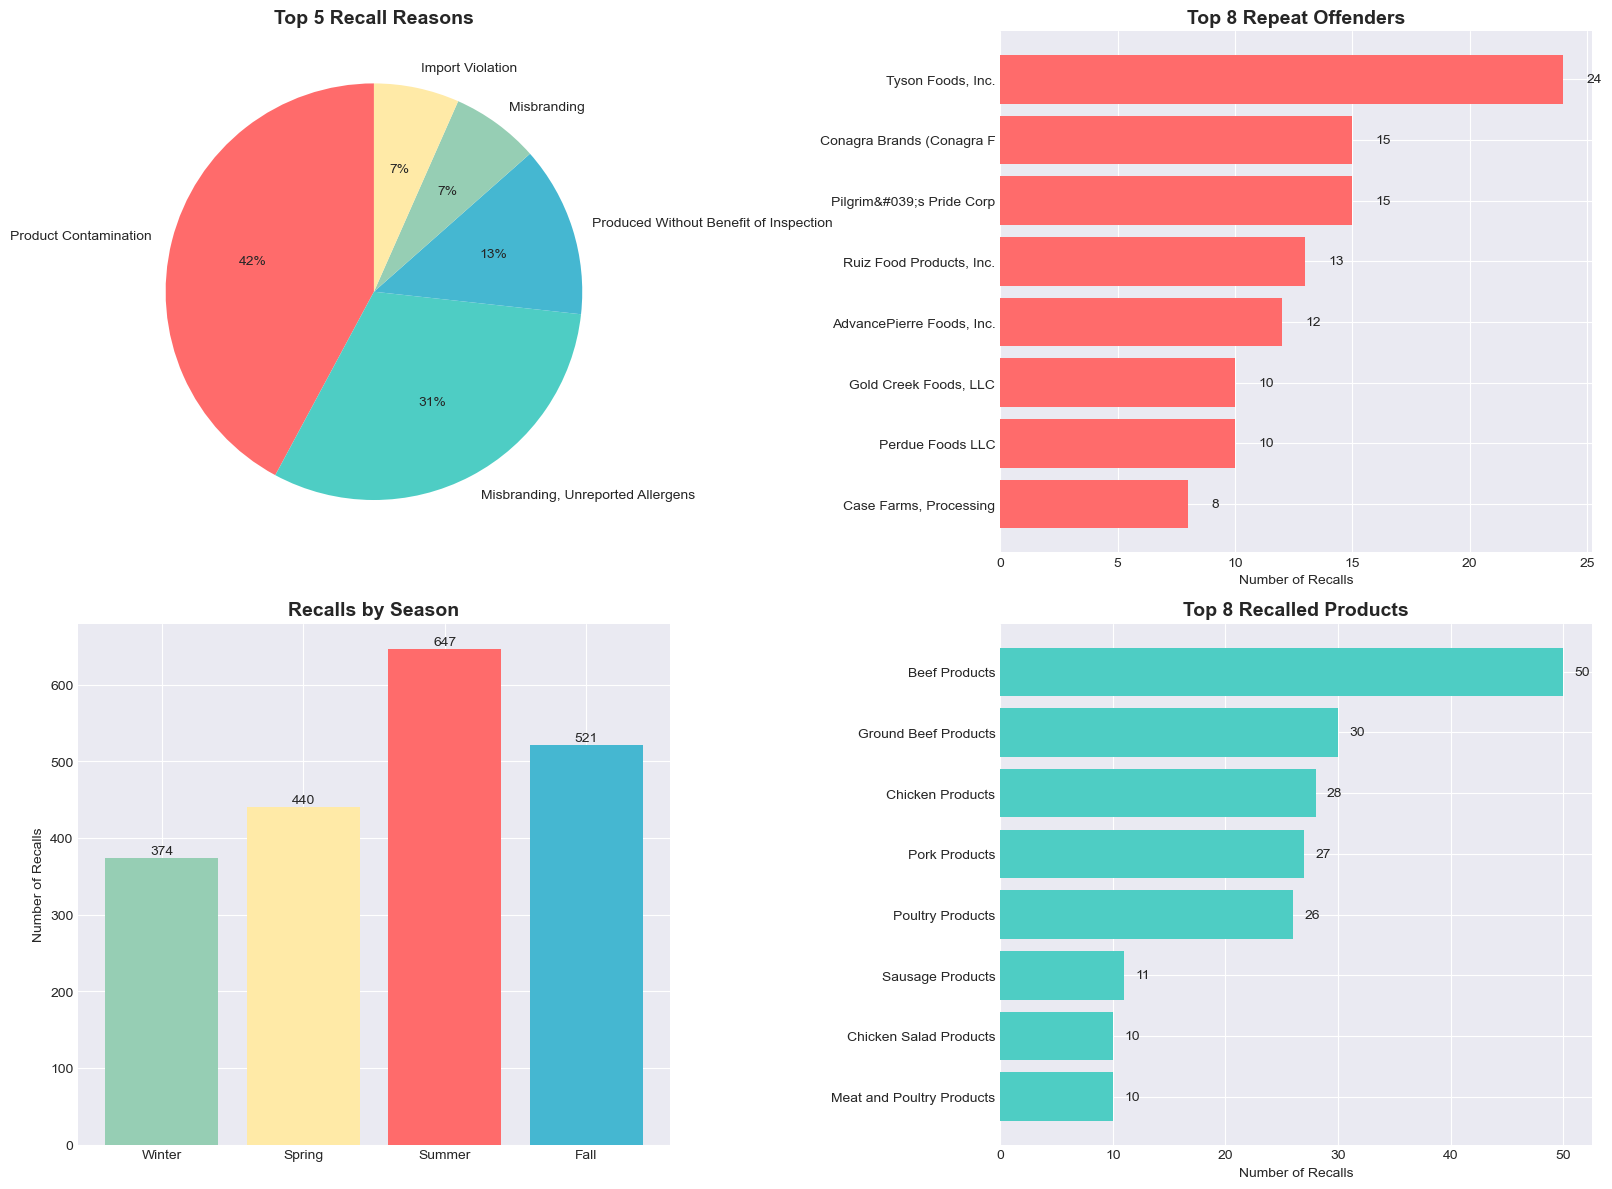

Visualizations saved as 'food_recalls_analysis.png'


In [15]:
import matplotlib.pyplot as plt 
import seaborn as sns

#Set style for professional looking charts 
plt.style.use('seaborn-v0_8-darkgrid') 
sns.set_palette("Set2") 

#Create a figure with multiple subplots
fig = plt.figure(figsize=(16,12))

# ============================================
# CHART 1: Top Recall Reasons (Pie Chart)
# ============================================
ax1 = fig.add_subplot(2,2,1)
top_reasons = df['field_recall_reason'].value_counts().head(5)
colors = ['#ff6b6b' , '#4ecdc4' , '#45b7d1', '#96ceb4', '#ffeaa7']
ax1.pie(top_reasons.values, labels=top_reasons.index, autopct='%1.0f%%', colors=colors, startangle=90)
ax1.set_title('Top 5 Recall Reasons', fontsize=14, fontweight='bold')

# ============================================
# CHART 2: Repeat Offenders (Bar Chart)
# ============================================
ax2 = fig.add_subplot(2, 2, 2)
top_companies = df[df['field_establishment'] != '']['field_establishment'].value_counts().head(8)
bars = ax2.barh(range(len(top_companies)), top_companies.values, color='#ff6b6b')
ax2.set_yticks(range(len(top_companies)))
ax2.set_yticklabels([c[:25] for c in top_companies.index])
ax2.set_xlabel('Number of Recalls')
ax2.set_title('Top 8 Repeat Offenders', fontsize=14, fontweight='bold')
ax2.invert_yaxis()

# Add value labels on bars
for i, v in enumerate(top_companies.values):
    ax2.text(v + 1, i, str(v), va='center')

# ============================================
# CHART 3: Recalls by Season
# ============================================
ax3 = fig.add_subplot(2, 2, 3)
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_counts = df['season'].value_counts()
season_counts = season_counts.reindex(season_order)
bars = ax3.bar(season_order, season_counts.values, color=['#96ceb4', '#ffeaa7', '#ff6b6b', '#45b7d1'])
ax3.set_ylabel('Number of Recalls')
ax3.set_title('Recalls by Season', fontsize=14, fontweight='bold')
for bar, val in zip(bars, season_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center')

# ============================================
# CHART 4: Top Products Recalled
# ============================================
ax4 = fig.add_subplot(2, 2, 4)
# Filter out 'Unknown' for this chart
valid_products = df[df['extracted_product'] != 'Unknown']['extracted_product'].value_counts().head(8)
if len(valid_products) > 0:
    bars = ax4.barh(range(len(valid_products)), valid_products.values, color='#4ecdc4')
    ax4.set_yticks(range(len(valid_products)))
    ax4.set_yticklabels([p[:35] for p in valid_products.index])
    ax4.set_xlabel('Number of Recalls')
    ax4.set_title('Top 8 Recalled Products', fontsize=14, fontweight='bold')
    ax4.invert_yaxis()
    for i, v in enumerate(valid_products.values):
        ax4.text(v + 1, i, str(v), va='center')
else:
    ax4.text(0.5, 0.5, 'Product extraction needs refinement\n(see "Unknown" category)', 
             ha='center', va='center', transform=ax4.transAxes)

plt.tight_layout()
plt.savefig('food_recalls_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualizations saved as 'food_recalls_analysis.png'")


## 15. Key Findings & Recommendations 

### Key Findings

| Finding | Insight |
|---------|---------|
| **Product Contamination** is #1 recall reason | 37% of all recalls |
| **Beef Products** are the most recalled | 22 recalls (most of any product category) |
| **Tyson Foods** has 24 recalls | 92% due to contamination |
| **Summer** has peak recalls | 32% of recalls occur in Summer |
| **Pilgrim's Pride** has 15 recalls | All 15 recalls = Product Contamination |
| **Conagra Brands** peaks in Fall | 53% of recalls occur in Fall (unique pattern) |

### Recommendations for Food Distributors 

Based on the analysis of 1,982 FDA food recalls (2012 - 2025), the following recommendations are proposed for food distributors and quality assurance teams: 

1. **Supplier Audit & Enforcement:**

Finding: Multiple companies, including Tyson Foods (24 recalls) Pilgrim's Pride (15 recalls), and Conagra Brands (15 recalls) demonstrate recurring recall patterns with 80 - 100% of incident attributed to Product Contamination.

**Recommendation**: 
Implement a tiered supplier enforcement program for repeat offenders: 

- Manadatory unannounced audits at facilities with >2 recalls annually.
- Third - party laboratory testing of finished products before distribution.
- Contractual penalties for recurring contamination issues.
- Suspension or termination of supplier agreements after 3 contamination- related recalls within 12 months.

>Companies that have been identified as repeat offenders should face stricter oversight, including unannounced facility, inspections, manadatory lab testing, and escalating consequences for recurring violations.

2. **Seasonal Quality Control:**

Finding: Summer months (June - August) account for 32% of all recalls - the highest of any season. Tyson Foods, Pilgrim's Pride, and Ruiz Food Products show 46-67% of their recalls occurring in Summer.

**Recommendation**: 
Increase facility temperature monitoring during Summer months (potential link between heat and contamination risk):

- Conduct pre-season equipment deep cleaning before June.
- Add random product sampling at 2x normal frequency during June-July.
- Review cold chain logistics for all temperature-sensitive products.

>Seasonal recall patterns suggest temperature-related vulnerabilities. Quality checks should be intensified not just for products, but also for facility environments — particularly refrigeration units, processing line temperatures, and employee hygiene stations during warmer months.

3. **Allergen Labeling Compliance:**

Finding: Misbranding and Unreported Allergens is the second most common recall reason (545 recalls, 27.5% of total) affecting companies accross all tiers. 

**Recommendation:**
Strengthen labeling processes through:

- Double-verification system for all ingredient and allergen declarations.
- Pre-production label audits for any recipe or packaging change.
- Automated allergen detection using software-based label verification tools.
- Quarterly labeling compliance training for quality and packaging teams.

>Allergen-related recalls are largely preventable. A systematic review of labeling processes, combined with verification checkpoints before production, can significantly reduce misbranding incidents.

4. **Product-Specific Monitoring:**

Finding: Extracted product analysis reveals that chicken nuggets, beef products, and ready-to-eat meals are among the most frequently recalls items. 

**Recommendations:** 
Establish product- specific risk profiles: 

-Prioritize Poultry Products for enhanced testing protocols.
-Implement additional foreign mattern detection (metal detectors, X-ray systems) for high- risk product lines.
-Create rapid response protocols for ready-to-eat meal categories.

>High risk products must have strict enhanced testing protocols. A microbiological testing protocols along with chemical and physical checkpoints before distribution, can significantly reduce recalls. 

### 16. Conclusion

>Beyond these recommendations, all companies must foster a strong food safety culture through leadership commitment, continuous employee training, and thorough checkpoints at every production stage. Recalls are rarely isolated incidents, they are symptoms of systematic failures. Without embedding safety into daily operations, repeat violations will continue regardless of external oversight. 

### 17. Limitations

- Product extraction still shows ~41% as "Unknown".
- No geographic analysis included.
- Limited to US data only.

### 18. Next Steps 

- Incorporate CFIA (Canadian) Recall data.
- Add geographic analysis by state. 
- Build interactive Tableau Dashboard.
